# Install

In [0]:
%pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 MB 93.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install "ray[tune]" hyperopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 973.5/973.5 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 MB 64.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Import

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
# Ray Imports
import ray
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch

# Data

In [0]:
FNOL_pdf = pd.read_excel("/Volumes/workspace/default/hastings_direct/Data_Scientist_Interview_FNOL_Data.xlsx")
FNOL_pdf[['Incurred', 'Capped Incurred']] = FNOL_pdf[['Incurred', 'Capped Incurred']].round(0).astype(int)
FNOL_pdf = FNOL_pdf.drop(columns=["Claim Number","Loss_code", "Loss_description", "TP_type_insd_pass_front", 'TP_type_pass_multi'])
region_cols = [
    'TP_region_eastang', 'TP_region_eastmid', 'TP_region_london', 
    'TP_region_north', 'TP_region_northw', 'TP_region_outerldn', 
    'TP_region_scotland', 'TP_region_southe', 'TP_region_southw', 
    'TP_region_wales', 'TP_region_westmid', 'TP_region_yorkshire'
]

# 1. Clean all regional columns and convert string placeholders to clean integers
for col in region_cols:
    FNOL_pdf[col] = pd.to_numeric(FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), errors='coerce'
    ).fillna(0).astype(int)

# 2. Total third-party headcount aggregated across all regions
FNOL_pdf['Total_Regional_TP_Count'] = FNOL_pdf[region_cols].sum(axis=1)

# 3. Define tie-aware primary region extraction logic
def get_primary_region(row):
    # Filter active regions with headcounts > 0
    active_regions = row[region_cols][row[region_cols] > 0]
    
    if active_regions.empty:
        return 'None_Recorded'
    
    max_val = active_regions.max()
    top_regions = active_regions[active_regions == max_val].index.tolist()
    
    # If a single region clearly leads in headcount
    if len(top_regions) == 1:
        return top_regions[0].replace('TP_region_', '')
    
    # If there is a headcount tie between two or more top regions
    return 'Multi_Region_Tie'

# 4. Apply the tie-aware function row-by-row
FNOL_pdf['Primary_TP_Region'] = FNOL_pdf.apply(get_primary_region, axis=1)
FNOL_pdf = FNOL_pdf.drop(columns=region_cols)
# List of all 9 third-party type features
all_tp_type_cols = [
    'TP_type_insd_pass_back', 'TP_type_driver', 'TP_type_pass_back', 
    'TP_type_pass_front', 'TP_type_bike', 'TP_type_cyclist', 
    'TP_type_pedestrian', 'TP_type_other', 'TP_type_nk'
]

# 1. Clean all 9 columns (convert placeholders '-', 'n/k', '#' to 0)
for col in all_tp_type_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = pd.to_numeric(
            FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), 
            errors='coerce'
        ).fillna(0).astype(int)

# 2. Feature 1: Total Passenger Count (Front + Back Passengers)
FNOL_pdf['Total_TP_Passenger_Count'] = (
    FNOL_pdf['TP_type_pass_front'] + FNOL_pdf['TP_type_pass_back'] + FNOL_pdf['TP_type_insd_pass_back']
)

# 3. Feature 2: Vulnerable Road User Flag (Bikes, Cyclists, Pedestrians)
FNOL_pdf['Has_Vulnerable_Road_User'] = (
    (FNOL_pdf['TP_type_bike'] > 0) | 
    (FNOL_pdf['TP_type_cyclist'] > 0) | 
    (FNOL_pdf['TP_type_pedestrian'] > 0)
).astype(int)

# 4. Feature 3: Overall TP Count (Includes ALL 9 columns, including TP_type_nk)
existing_cols = [c for c in all_tp_type_cols if c in FNOL_pdf.columns]
FNOL_pdf['Total_TP_Type_Count'] = FNOL_pdf[existing_cols].sum(axis=1)
FNOL_pdf = FNOL_pdf.drop(columns=all_tp_type_cols)
# List of the 5 raw TP injury columns
injury_cols = ['TP_injury_whiplash', 'TP_injury_traumatic', 'TP_injury_fatality', 'TP_injury_unclear', 'TP_injury_nk']

# 1. Clean missing placeholders ('-', 'n/k', '#') across all 5 columns
for col in injury_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = pd.to_numeric(
            FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), 
            errors='coerce'
        ).fillna(0).astype(int)

# 2. Define the hierarchical severity function
def determine_max_injury_tier(row):
    # Tier 4: Fatality (Highest priority)
    if row.get('TP_injury_fatality', 0) > 0:
        return 4
    # Tier 3: Traumatic / Severe Body Injury
    elif row.get('TP_injury_traumatic', 0) > 0:
        return 3
    # Tier 2: Whiplash / Soft Tissue Injury
    elif row.get('TP_injury_whiplash', 0) > 0:
        return 2
    # Tier 1: Unclear or Not Known Injury details reported
    elif row.get('TP_injury_unclear', 0) > 0 or row.get('TP_injury_nk', 0) > 0:
        return 1
    # Tier 0: No Injury Recorded
    else:
        return 0

# 3. Apply the hierarchy row-by-row
FNOL_pdf['Max_Injury_Severity_Tier'] = FNOL_pdf.apply(determine_max_injury_tier, axis=1)

# 4. Optional: Also capture total count of injured third parties
FNOL_pdf['Total_Injured_TP_Count'] = FNOL_pdf[injury_cols].sum(axis=1)
FNOL_pdf = FNOL_pdf.drop(columns=injury_cols)
# 1. Identify your date column (replace 'date_of_loss' with your exact column name if different)
date_col = 'date_of_loss'

# 2. Convert to Pandas datetime format (handles formats like 'YYYY-MM-DD', 'DD/MM/YYYY', etc.)
FNOL_pdf[date_col] = pd.to_datetime(FNOL_pdf[date_col], errors='coerce')

# 3. Extract cyclical and temporal components
FNOL_pdf['loss_year'] = FNOL_pdf[date_col].dt.year
FNOL_pdf['loss_month'] = FNOL_pdf[date_col].dt.month
FNOL_pdf['loss_day_of_week'] = FNOL_pdf[date_col].dt.day_name()
FNOL_pdf = FNOL_pdf.drop(columns=date_col)
FNOL_pdf = FNOL_pdf.drop(columns="Incurred")
import numpy as np

# 1. Define your 10 categorical columns
cat_cols = [
    'Notifier', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile', 'Main_driver', 
    'PH_considered_TP_at_fault', 'Primary_TP_Region', 'loss_day_of_week'
]

# 2. Define missing value placeholders and casing standardizations
missing_placeholders = ['N/K', 'n/k', 'NK', 'nk', '-', '#', 'n/a', 'N/A', 'None', 'nan', '', 'Not Applicable']
casing_fixes = {'other': 'OTHER', 'Other': 'OTHER', 'unknown': 'UNKNOWN', 'Unknown': 'UNKNOWN'}

# 3. Process all 10 columns in a single loop
for col in cat_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = (
            FNOL_pdf[col]
            .astype(str)                           # Ensure string type for reliable replacement
            .str.strip()                           # Strip leading/trailing whitespace
            .replace(missing_placeholders, np.nan) # Map unknown placeholders to true NaN
            .replace(casing_fixes)                # Standardize 'Other' casing
            .astype('category')                    # Convert to category for XGBoost
        )
FNOL_pdf = FNOL_pdf[(FNOL_pdf['Notification_period'] >= 0) & (FNOL_pdf['Capped Incurred'] >= 0)]
FNOL_pdf.head()


,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count,loss_year,loss_month,loss_day_of_week
0,PH,22,13,Main Road,NORMAL,Y,10,OTHER,NaN,1,0,0,0,1,northw,0,0,1,1,1,2003,4,Tuesday
1,CNF,1,9,Main Road,WET,Y,18,OTHER,NaN,1,1,0,2801,1,southe,0,0,1,1,1,2003,4,Sunday
2,CNF,5,17,Main Road,WET,Y,16,Y,NaN,1,0,0,1221,1,northw,0,0,1,1,1,2003,4,Thursday
3,CNF,1,23,Main Road,NaN,Y,14,OTHER,NaN,1,1,0,3530,1,westmid,0,0,1,1,1,2003,5,Tuesday
4,CNF,1,48,OTHER,NaN,N,9,OTHER,NaN,1,1,0,3156,0,None_Recorded,0,0,1,1,2,2003,6,Wednesday


# Run the experiment with parameter tunning,choose best model and logged in mlflow 

2026-09-13 19:55:10,166	WARNING services.py:2248 -- WARNING: The object store is using /local_disk0/tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.85gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-09-13 19:55:11,567	INFO worker.py:2024 -- Started a local Ray instance.
2026-09-13 19:55:12,690	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.


+----------------------------------------------------------------------------+
| Configuration for experiment     trainable_objective_2026-09-13_19-55-12   |
+----------------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                           |
| Scheduler                        FIFOScheduler                             |
| Number of trials                 20                                        |
+----------------------------------------------------------------------------+

View detailed results here: /home/spark-60ff3890-e8ce-42ed-8ef5-71/ray_results/trainable_objective_2026-09-13_19-55-12
To visualize your results with TensorBoard, run: `tensorboard --logdir /local_disk0/tmp/ray/session_2026-09-13_19-55-08_800575_70/artifacts/2026-09-13_19-55-12/trainable_objective_2026-09-13_19-55-12/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-09-13 19:55:15. Total running time: 0s
Logical resource usage: 1.

(trainable_objective pid=1520) Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0xffb4ad588900>
(trainable_objective pid=1520) Traceback (most recent call last):
(trainable_objective pid=1520)   File "/usr/lib/python3.12/_weakrefset.py", line 39, in _remove
(trainable_objective pid=1520)     def _remove(item, selfref=ref(self)):
(trainable_objective pid=1520) 
(trainable_objective pid=1520)   File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-60ff3890-e8ce-42ed-8ef5-71a1a0986978/lib/python3.12/site-packages/ray/_private/worker.py", line 1060, in sigterm_handler
(trainable_objective pid=1520)     raise_sys_exit_with_custom_error_message(
(trainable_objective pid=1520)   File "python/ray/_raylet.pyx", line 714, in ray._raylet.raise_sys_exit_with_custom_error_message
(trainable_objective pid=1520) SystemExit: 1



Trial trainable_objective_4b11d79e started with configuration:
+----------------------------------------------------+
| Trial trainable_objective_4b11d79e config          |
+----------------------------------------------------+
| colsample_bytree                               0.6 |
| learning_rate                                 0.05 |
| max_depth                                        3 |
| n_estimators                                   300 |
| reg_alpha                                        5 |
| reg_lambda                                       5 |
| subsample                                      0.7 |
| tweedie_variance_power                         1.3 |
+----------------------------------------------------+

Trial trainable_objective_4b11d79e completed after 1 iterations at 2026-09-13 19:55:50. Total running time: 34s
+-----------------------------------------------------------+
| Trial trainable_objective_4b11d79e result                 |
+--------------------------------------

2026-09-13 19:56:07,983	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-60ff3890-e8ce-42ed-8ef5-71/ray_results/trainable_objective_2026-09-13_19-55-12' in 0.0218s.



Trial trainable_objective_eca0709e completed after 1 iterations at 2026-09-13 19:56:07. Total running time: 52s
+-----------------------------------------------------------+
| Trial trainable_objective_eca0709e result                 |
+-----------------------------------------------------------+
| checkpoint_dir_name                                       |
| time_this_iter_s                                  1.26524 |
| time_total_s                                      1.26524 |
| training_iteration                                      1 |
| rmse                                                10573 |
| test_mae                                          4569.87 |
| test_mape                                     6.86383e+06 |
| test_rmse                                         9636.76 |
| train_mae                                         4853.05 |
| train_mape                                    4.55779e+06 |
| train_rmse                                        10266.2 |
| val_mae          

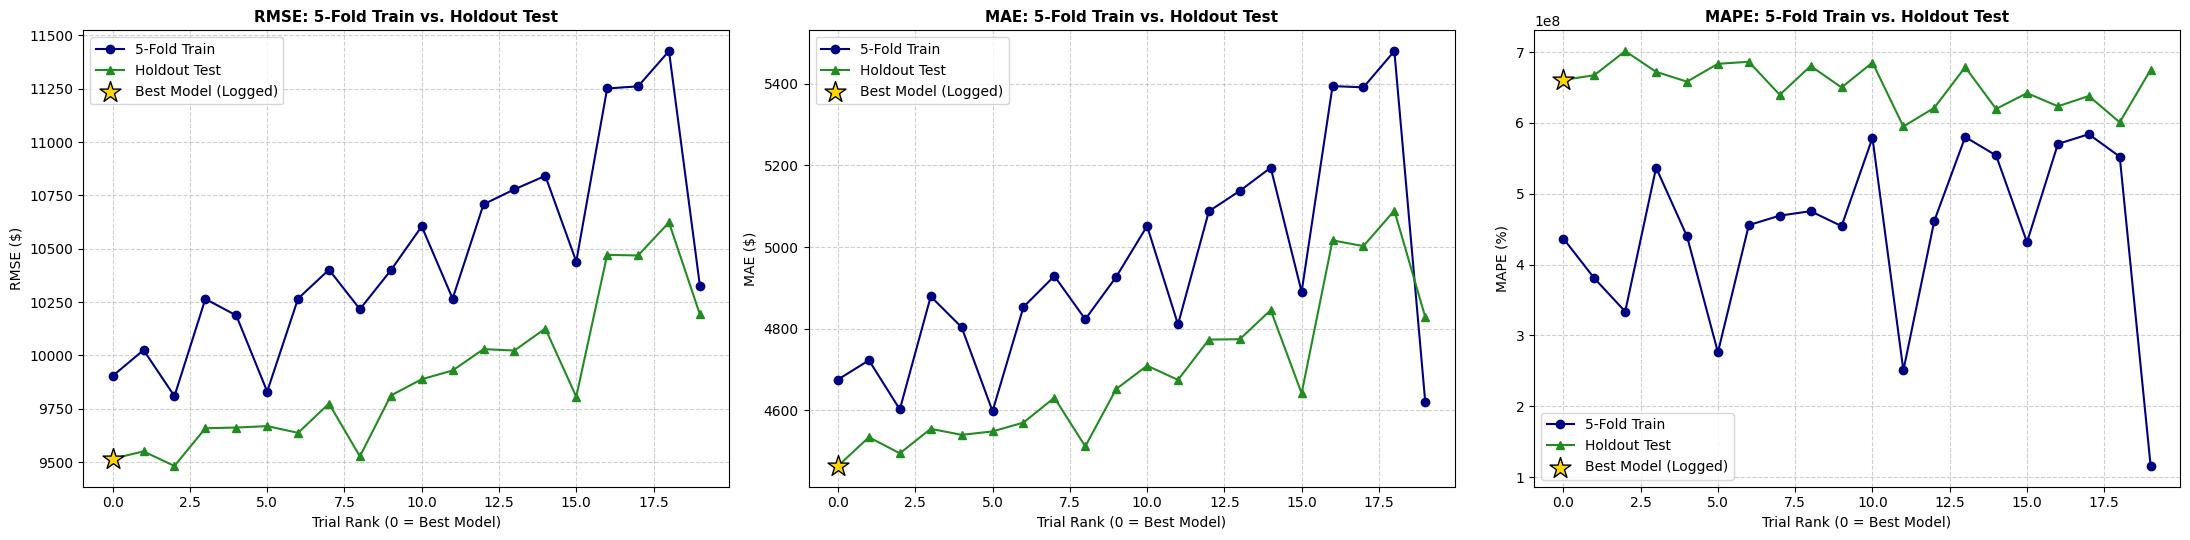

2026/09/13 19:56:14 INFO mlflow.tracking.fluent: Experiment with name '/Users/mehdiborhanfar@gmail.com/XGBoost_FNOL_One_stage_modeling' does not exist. Creating a new experiment.
2026/09/13 19:56:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-d7f1c5e3-bdfc.cloud.databricks.com/ml/experiments/3518190807622145/models/m-be7003f6289842b29641d660dd8dc496?o=7474652645564939
/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whene


Logged Best Model Run ID: 9123bed69f374663b949970d353fa1e9
Final Holdout Test Metrics -> RMSE: $9515.90 | MAE: $4463.49 | MAPE: 660767409.72% | R² Score: 0.1797


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
import xgboost as xgb

# Ray Imports
import ray
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch

# 1. Define Feature Lists
categorical_features = [
    'Notifier', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile',
    'Main_driver', 'PH_considered_TP_at_fault', 'Primary_TP_Region', 'loss_day_of_week',
]

numerical_features = [
    'Notification_period', 'Inception_to_loss', 'Time_hour',
    'Vechile_registration_present', 'Incident_details_present', 'Injury_details_present',
    'Total_Regional_TP_Count', 'Total_TP_Passenger_Count', 'Has_Vulnerable_Road_User',
    'Total_TP_Type_Count', 'Max_Injury_Severity_Tier', 'Total_Injured_TP_Count',
    'loss_year', 'loss_month',
]

all_features = categorical_features + numerical_features

# 2. Extract Features and Continuous Regression Target
X = FNOL_pdf[all_features].copy()
y = FNOL_pdf["Capped Incurred"].copy()  # Continuous target for Stage 2 Regression

# 3. Train / Test Split (80% Dev for 5-Fold CV, 20% Holdout Test)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

y_dev = pd.Series(y_dev).reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)

# 4. Pre-transform Data for Fast Ray Tune Execution
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_dev_trans = preprocessor.fit_transform(X_dev)
X_test_trans = preprocessor.transform(X_test)

# Put datasets into Ray Object Store
X_dev_ref = ray.put(X_dev_trans)
y_dev_ref = ray.put(y_dev.values)
X_test_ref = ray.put(X_test_trans)
y_test_ref = ray.put(y_test.values)

# 5. Ray Tune Objective Function with Tweedie Loss
def trainable_objective(config):
    X_d = ray.get(X_dev_ref)
    y_d = ray.get(y_dev_ref)
    X_te = ray.get(X_test_ref)
    y_te = ray.get(y_test_ref)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_tr_rmse, cv_val_rmse = [], []
    cv_tr_mae, cv_val_mae = [], []
    cv_tr_mape, cv_val_mape = [], []

    for train_idx, val_idx in kf.split(X_d, y_d):
        X_tr, X_va = X_d[train_idx], X_d[val_idx]
        y_tr, y_va = y_d[train_idx], y_d[val_idx]

        # XGBoost with Tweedie Loss Objective for Insurance Claims
        xgb_model = xgb.XGBRegressor(
            objective='reg:tweedie',
            tweedie_variance_power=config["tweedie_variance_power"],
            max_depth=int(config["max_depth"]),
            learning_rate=config["learning_rate"],
            n_estimators=int(config["n_estimators"]),
            subsample=config["subsample"],
            colsample_bytree=config["colsample_bytree"],
            reg_alpha=config["reg_alpha"],
            reg_lambda=config["reg_lambda"],
            missing=np.nan,
            random_state=42
        )

        
        model = TransformedTargetRegressor(
            regressor=xgb_model
        )

        model.fit(X_tr, y_tr)

        # Fold Train Metrics (Calculated on Original Dollar Scale)
        y_tr_pred = np.maximum(0, model.predict(X_tr))
        cv_tr_rmse.append(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))
        cv_tr_mae.append(mean_absolute_error(y_tr, y_tr_pred))
        cv_tr_mape.append(mean_absolute_percentage_error(y_tr + 1e-5, y_tr_pred))

        # Fold Validation Metrics
        y_val_pred = np.maximum(0, model.predict(X_va))
        cv_val_rmse.append(np.sqrt(mean_squared_error(y_va, y_val_pred)))
        cv_val_mae.append(mean_absolute_error(y_va, y_val_pred))
        cv_val_mape.append(mean_absolute_percentage_error(y_va + 1e-5, y_val_pred))

    # Evaluate Holdout Test Set with Model Trained on Full Dev Set
    final_cv_xgb = xgb.XGBRegressor(
        objective='reg:tweedie',
        tweedie_variance_power=config["tweedie_variance_power"],
        max_depth=int(config["max_depth"]),
        learning_rate=config["learning_rate"],
        n_estimators=int(config["n_estimators"]),
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        reg_alpha=config["reg_alpha"],
        reg_lambda=config["reg_lambda"],
        missing=np.nan,
        random_state=42
    )
    final_cv_model = TransformedTargetRegressor(
        regressor=final_cv_xgb
    )
    final_cv_model.fit(X_d, y_d)
    
    y_te_pred = np.maximum(0, final_cv_model.predict(X_te))
    te_rmse = np.sqrt(mean_squared_error(y_te, y_te_pred))
    te_mae = mean_absolute_error(y_te, y_te_pred)
    te_mape = mean_absolute_percentage_error(y_te + 1e-5, y_te_pred)

    tune.report(metrics={
        "train_rmse": np.mean(cv_tr_rmse),
        "train_mae": np.mean(cv_tr_mae),
        "train_mape": np.mean(cv_tr_mape),
        "val_rmse": np.mean(cv_val_rmse),
        "val_mae": np.mean(cv_val_mae),
        "val_mape": np.mean(cv_val_mape),
        "test_rmse": te_rmse,
        "test_mae": te_mae,
        "test_mape": te_mape,
        "rmse": np.mean(cv_val_rmse)  # Target metric for optimization
    })

# 6. Ray Tune Search Setup (Minimizing RMSE with Tweedie Parameters)
ray.init(ignore_reinit_error=True)

search_space = {
    "tweedie_variance_power": tune.choice([1.1, 1.3, 1.5, 1.7]),
    "max_depth": tune.choice([3, 4, 6]),
    "learning_rate": tune.choice([0.01, 0.03, 0.05]),
    "n_estimators": tune.choice([100, 200, 300]),
    "subsample": tune.choice([0.6, 0.7, 0.8]),
    "colsample_bytree": tune.choice([0.5, 0.6, 0.7]),
    "reg_alpha": tune.choice([0.5, 1.0, 5.0]),
    "reg_lambda": tune.choice([3.0, 5.0, 10.0])
}

hyperopt_search = HyperOptSearch(metric="rmse", mode="min")

tuner = tune.Tuner(
    trainable_objective,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        search_alg=hyperopt_search,
        num_samples=20,
    )
)

results = tuner.fit()
best_result = results.get_best_result(metric="rmse", mode="min")
best_config = best_result.config

# 7. Generate Diagnostic Plots (RMSE, MAE, and MAPE) with Best Model Annotations
results_df = results.get_dataframe()
results_df = results_df.sort_values(by="val_rmse", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))

metrics_to_plot = [
    ("train_rmse", "test_rmse", "RMSE ($)", "RMSE: 5-Fold Train vs. Holdout Test"),
    ("train_mae", "test_mae", "MAE ($)", "MAE: 5-Fold Train vs. Holdout Test"),
    ("train_mape", "test_mape", "MAPE (%)", "MAPE: 5-Fold Train vs. Holdout Test")
]

for idx, (tr_col, te_col, ylabel, title) in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Scale MAPE for display if plotting percentages
    scale = 100 if "mape" in tr_col else 1.0
    
    ax.plot(results_df.index, results_df[tr_col] * scale, marker='o', label="5-Fold Train", color='navy')
    ax.plot(results_df.index, results_df[te_col] * scale, marker='^', label="Holdout Test", color='forestgreen')
    
    # Highlight Best Model (Rank 0) with Gold Star
    best_val = results_df.loc[0, te_col] * scale
    ax.scatter(0, best_val, color='gold', s=250, zorder=6, edgecolors='black', marker='*', label="Best Model (Logged)")
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Trial Rank (0 = Best Model)")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plot_filename = "cv_train_val_test_overfitting_tweedie_regression.png"
plt.savefig(plot_filename)
plt.show()

# 8. Re-train Final Pipeline on Full Development Set & Log to MLflow
mlflow.set_experiment("/Users/" + spark.sql("SELECT current_user()").collect()[0][0] + "/XGBoost_FNOL_One_stage_modeling")

with mlflow.start_run(run_name="XGBoost_Tweedie_Log_Best_Model") as run:
    
    xgb_regressor = xgb.XGBRegressor(
        objective='reg:tweedie',
        tweedie_variance_power=best_config["tweedie_variance_power"],
        max_depth=int(best_config["max_depth"]),
        learning_rate=best_config["learning_rate"],
        n_estimators=int(best_config["n_estimators"]),
        subsample=best_config["subsample"],
        colsample_bytree=best_config["colsample_bytree"],
        reg_alpha=best_config["reg_alpha"],
        reg_lambda=best_config["reg_lambda"],
        missing=np.nan,
        random_state=42
    )

    best_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb_regressor)
    ])
    
    best_pipeline.fit(X_dev, y_dev)
    
    y_test_pred = np.maximum(0, best_pipeline.predict(X_test))
    
    # Calculate Final Holdout Regression Metrics
    final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    final_mae = mean_absolute_error(y_test, y_test_pred)
    final_mape = mean_absolute_percentage_error(y_test + 1e-5, y_test_pred)
    final_r2 = r2_score(y_test, y_test_pred)
    
    mlflow.log_params(best_config)
    mlflow.log_metrics({
        "test_rmse": final_rmse,
        "test_mae": final_mae,
        "test_mape": final_mape,
        "test_r2_score": final_r2
    })
    
    mlflow.log_artifact(plot_filename)
    
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="xgboost_fnol_pipeline_best",
        input_example=X_dev.iloc[:5]
    )

    print(f"\nLogged Best Model Run ID: {run.info.run_id}")
    print(
        f"Final Holdout Test Metrics -> "
        f"RMSE: ${final_rmse:.2f} | "
        f"MAE: ${final_mae:.2f} | "
        f"MAPE: {final_mape * 100:.2f}% | "
        f"R² Score: {final_r2:.4f}"
    )

Loading model from: runs:/9123bed69f374663b949970d353fa1e9/xgboost_fnol_pipeline_best



     REGRESSION MODEL PERFORMANCE EVALUATION
RMSE:         $9515.90
MAE:          $4463.49
R² Score:     0.1797

     TOP 15 FEATURE IMPORTANCES (REGRESSION)
                        Feature  Importance
       Max_Injury_Severity_Tier    0.252165
               Vehicle_mobile_N    0.089483
        Total_Regional_TP_Count    0.061455
    PH_considered_TP_at_fault_N    0.051184
               Vehicle_mobile_Y    0.046333
Primary_TP_Region_None_Recorded    0.041652
            Total_TP_Type_Count    0.034200
                      loss_year    0.023837
Location_of_incident_Minor Road    0.019761
Weather_conditions_SNOW,ICE,FOG    0.019733
      Weather_conditions_NORMAL    0.019270
    PH_considered_TP_at_fault_Y    0.017790
                 Notifier_OTHER    0.016520
         Weather_conditions_WET    0.016278
       loss_day_of_week_Tuesday    0.014244


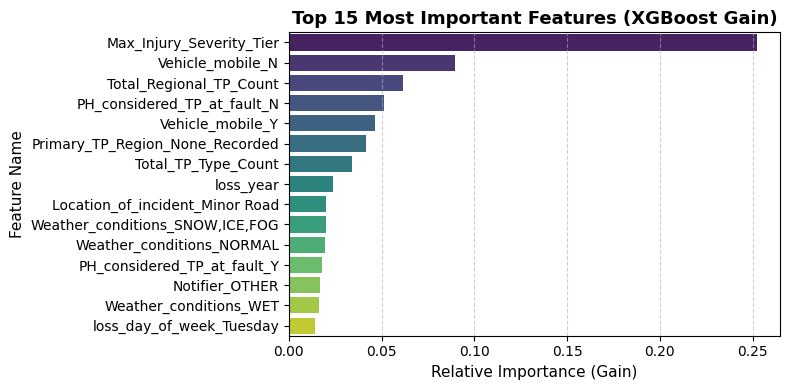

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# -------------------------------------------------------------------------
# 1. Load the Regression Model from MLflow using Run ID
# -------------------------------------------------------------------------
run_id = "9123bed69f374663b949970d353fa1e9"  # Replace with your actual Regression Run ID
artifact_path = (
    "xgboost_fnol_pipeline_best"  # Match the regression artifact path logged during training
)

model_uri = f"runs:/{run_id}/{artifact_path}"
print(f"Loading model from: {model_uri}")

# Load the full Scikit-Learn Pipeline (OneHotEncoder + XGBRegressor)
loaded_pipeline = mlflow.sklearn.load_model(model_uri)

# -------------------------------------------------------------------------
# 2. Predict on Data and Evaluate Regression Performance
# -------------------------------------------------------------------------
# Pass raw X_test directly - the pipeline handles feature transformations
y_pred = loaded_pipeline.predict(X_test)

# Calculate Regression Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("     REGRESSION MODEL PERFORMANCE EVALUATION")
print("=" * 40)
print(f"RMSE:         ${rmse:.2f}")
print(f"MAE:          ${mae:.2f}")
print(f"R² Score:     {r2:.4f}")

# -------------------------------------------------------------------------
# 3. Extract Feature Importances (Safely Unwraps Target Regressor)
# -------------------------------------------------------------------------
# Extract fitted steps from the pipeline
preprocessor = loaded_pipeline.named_steps["preprocessor"]
model_step = loaded_pipeline.named_steps["regressor"]

# Safely extract underlying model if wrapped in TransformedTargetRegressor
if hasattr(model_step, "regressor_"):
    xgb_model = model_step.regressor_
else:
    xgb_model = model_step

# Get encoded categorical feature names from OneHotEncoder
cat_encoder = preprocessor.named_transformers_["cat"]
encoded_cat_features = list(
    cat_encoder.get_feature_names_out(categorical_features)
)

# Combine with numerical features in exact pipeline processing order
feature_names = encoded_cat_features + numerical_features

# Extract gain-based feature importances from XGBRegressor
importances = xgb_model.feature_importances_

# Construct DataFrame
feature_imp_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 40)
print("     TOP 15 FEATURE IMPORTANCES (REGRESSION)")
print("=" * 40)
print(feature_imp_df.head(15).to_string(index=False))

# -------------------------------------------------------------------------
# 4. Plot Feature Importances
# -------------------------------------------------------------------------
top_15_df = feature_imp_df.head(15)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_15_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("Top 15 Most Important Features (XGBoost Gain)", fontsize=13, fontweight="bold")
plt.xlabel("Relative Importance (Gain)", fontsize=11)
plt.ylabel("Feature Name", fontsize=11)
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Performance of the model on all data

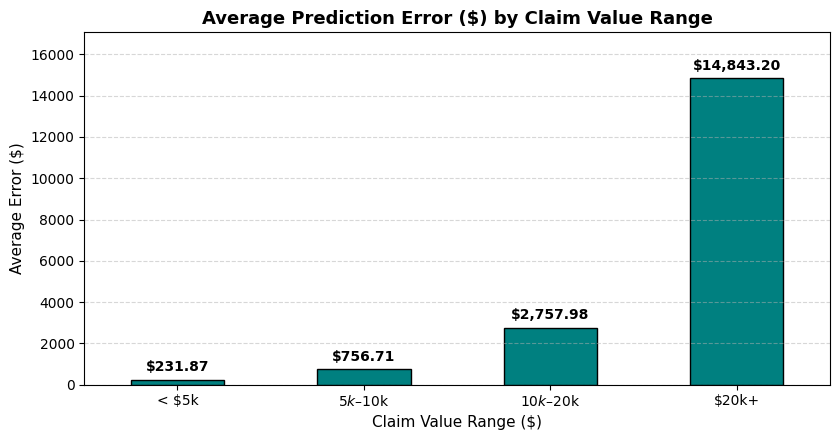

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Create temporary evaluation dataframe
eval_df = pd.DataFrame(
    {
        "True_Value": FNOL_pdf["Capped Incurred"],
        "Predicted_Value": loaded_pipeline.predict(FNOL_pdf[all_features]),
    }
)

eval_df["Abs_Difference"] = (
    eval_df["Predicted_Value"] - eval_df["True_Value"]
).abs()

# Set custom x-axis category names directly in qcut
custom_labels = ["< $5k", "$5k–$10k", "$10k–$20k", "$20k+"]
eval_df["Error_Tier"] = pd.qcut(
    eval_df["True_Value"], q=4, labels=custom_labels
)

# Group by tier
tier_summary = eval_df.groupby("Error_Tier", observed=False)[
    "Abs_Difference"
].mean()

# Plot
plt.figure(figsize=(8.5, 4.5))
ax = tier_summary.plot(kind="bar", color="#008080", edgecolor="black")

# Format bar top values
ax.bar_label(ax.containers[0], fmt="${:,.2f}", padding=4, fontweight="bold")
plt.ylim(0, tier_summary.max() * 1.15)

# Styling
plt.title(
    "Average Prediction Error ($) by Claim Value Range",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Claim Value Range ($)", fontsize=11)
plt.ylabel("Average Error ($)", fontsize=11)
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [0]:
import numpy as np
import pandas as pd

# 1. Define custom monetary bands
bins = [0, 5000, 10000, 20000, np.inf]
labels = ["< $5k", "$5k–$10k", "$10k–$20k", "$20k+"]

# 2. Assign claim bands
FNOL_pdf["Claim_Band"] = pd.cut(
    FNOL_pdf["Capped Incurred"], bins=bins, labels=labels, include_lowest=True
)

# 3. Calculate count and percentage distribution
distribution_df = (
    FNOL_pdf["Claim_Band"]
    .value_counts(sort=False)
    .rename_axis("Claim Value Range")
    .reset_index(name="Claim Count")
)

distribution_df["Percentage (%)"] = (
    distribution_df["Claim Count"] / len(FNOL_pdf) * 100
).round(2)

print(distribution_df)

  Claim Value Range  Claim Count  Percentage (%)
0             < $5k         5465           71.52
1          $5k–$10k          722            9.45
2         $10k–$20k          715            9.36
3             $20k+          739            9.67
